In [ ]:
import numpy as np
import random
import pandas as pd
from sklearn.decomposition import PCA
from matplotlib import pyplot as plt

In [ ]:
!wget ftp://cluster.inr.ac.ru/pub/ML/3FGL/3fgl_full.dat

--2025-11-06 16:03:58--  ftp://cluster.inr.ac.ru/pub/ML/3FGL/3fgl_full.dat
           => ‘3fgl_full.dat.3’
Resolving cluster.inr.ac.ru (cluster.inr.ac.ru)... 185.207.91.225
Connecting to cluster.inr.ac.ru (cluster.inr.ac.ru)|185.207.91.225|:21... connected.
Logging in as anonymous ... Logged in!
==> SYST ... done.    ==> PWD ... done.
==> TYPE I ... done.  ==> CWD (1) /pub/ML/3FGL ... done.
==> SIZE 3fgl_full.dat ... 875698
==> PASV ... done.    ==> RETR 3fgl_full.dat ... done.
Length: 875698 (855K) (unauthoritative)

3fgl_full.dat.3     100%[===================>] 855.17K   141KB/s    in 7.2s    

2025-11-06 16:04:10 (119 KB/s) - ‘3fgl_full.dat.3’ saved [875698]



In [ ]:
data = np.loadtxt("3fgl_full.dat", dtype=str)
columns = ['Name','RA','Dec'] + ['Par' + str(i) for i in range(1,27)] + ['SourceType']
df = pd.DataFrame(data=data, columns=columns)
df

,Name,RA,Dec,Par1,Par2,Par3,Par4,Par5,Par6,Par7,...,Par18,Par19,Par20,Par21,Par22,Par23,Par24,Par25,Par26,SourceType
0,J0000.1+6545,0.0377,65.7517,0.0628,0.0481,41.030,6.813,1159.08,1.0053E-12,1.0160E-09,...,2.855343E-12,6.022,5.780520E-11,3.784131E-13,1.509,2.839629E-11,4.317204E-13,2.421,4.075352E+01,NULL
1,J0000.2-3738,0.0612,-37.6484,0.0451,0.0417,-88.550,5.091,3296.33,1.9420E-14,2.0387E-10,...,3.532782E-13,2.941,7.452389E-11,5.197980E-13,4.154,1.590734E-11,2.991650E-13,3.469,4.484532E+01,NULL
2,J0001.0+6314,0.2535,63.2440,0.1526,0.0986,-65.320,6.164,472.16,8.6247E-12,6.4037E-10,...,6.768034E-13,1.748,1.158661E-10,7.319140E-13,3.275,2.021964E-12,2.761839E-14,0.362,5.304786E+01,spp
3,J0001.2-0748,0.3209,-7.8159,0.0503,0.0429,-19.470,11.253,1263.84,4.8539E-13,6.9522E-10,...,1.236880E-12,6.997,2.106892E-10,1.421389E-12,8.018,1.005633E-11,1.686281E-13,1.574,4.973821E+01,bll
4,J0001.4+2120,0.3612,21.3379,0.1298,0.1162,-32.550,11.350,310.68,2.5221E-11,2.9449E-10,...,7.152622E-13,4.517,8.413887E-15,4.392482E-17,0.000,1.035538E-14,9.594525E-17,0.000,1.303363E+02,fsrq
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3029,J2358.5+3827,359.6342,38.4539,0.0622,0.0461,79.940,5.892,2814.47,4.8144E-14,3.8089E-10,...,7.105315E-13,3.873,7.908256E-11,5.380139E-13,4.051,3.489049E-11,6.018759E-13,3.435,5.231089E+01,NULL
3030,J2358.6-1809,359.6659,-18.1585,0.0445,0.0394,19.880,6.513,3925.48,2.1028E-14,3.0164E-10,...,4.460927E-13,3.343,1.212272E-10,8.506079E-13,5.529,3.124023E-11,6.000252E-13,4.136,4.880265E+01,NULL
3031,J2358.9+3926,359.7360,39.4476,0.1079,0.0879,10.360,4.685,2167.58,7.4583E-14,3.3950E-10,...,7.315058E-13,3.687,2.752512E-12,1.844227E-14,0.145,4.889366E-11,8.012898E-13,4.207,5.285284E+01,fsrq
3032,J2359.3-3038,359.8291,-30.6465,0.0335,0.0314,-6.680,11.055,2239.89,1.1999E-13,5.9432E-10,...,1.048397E-12,6.609,1.267952E-10,8.683160E-13,6.162,5.573432E-11,9.833648E-13,6.002,4.096702E+01,bll


In [ ]:
print(df.columns)

Index(['Name', 'RA', 'Dec', 'Par1', 'Par2', 'Par3', 'Par4', 'Par5', 'Par6',
       'Par7', 'Par8', 'Par9', 'Par10', 'Par11', 'Par12', 'Par13', 'Par14',
       'Par15', 'Par16', 'Par17', 'Par18', 'Par19', 'Par20', 'Par21', 'Par22',
       'Par23', 'Par24', 'Par25', 'Par26', 'SourceType'],
      dtype='object')


In [ ]:
df["RA"] = pd.to_numeric(df["RA"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3034 entries, 0 to 3033
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        3034 non-null   object 
 1   RA          3034 non-null   float64
 2   Dec         3034 non-null   object 
 3   Par1        3034 non-null   object 
 4   Par2        3034 non-null   object 
 5   Par3        3034 non-null   object 
 6   Par4        3034 non-null   object 
 7   Par5        3034 non-null   object 
 8   Par6        3034 non-null   object 
 9   Par7        3034 non-null   object 
 10  Par8        3034 non-null   object 
 11  Par9        3034 non-null   object 
 12  Par10       3034 non-null   object 
 13  Par11       3034 non-null   object 
 14  Par12       3034 non-null   object 
 15  Par13       3034 non-null   object 
 16  Par14       3034 non-null   object 
 17  Par15       3034 non-null   object 
 18  Par16       3034 non-null   object 
 19  Par17       3034 non-null  

In [ ]:
df.describe()

,RA
count,3034.000000
mean,185.637860
std,100.601810
min,0.037700
25%,102.768650
50%,189.986000
75%,270.376075
max,359.881200


In [ ]:
#преобразование типов нескольких колонок сразу
columns_to_convert = columns[1:-1]  #пропускаем нулевой и последний столбцы
df[columns_to_convert] = df[columns_to_convert].apply(pd.to_numeric)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3034 entries, 0 to 3033
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        3034 non-null   object 
 1   RA          3034 non-null   float64
 2   Dec         3034 non-null   float64
 3   Par1        3034 non-null   float64
 4   Par2        3034 non-null   float64
 5   Par3        3034 non-null   float64
 6   Par4        3034 non-null   float64
 7   Par5        3034 non-null   float64
 8   Par6        3034 non-null   float64
 9   Par7        3034 non-null   float64
 10  Par8        3034 non-null   float64
 11  Par9        3034 non-null   float64
 12  Par10       3034 non-null   float64
 13  Par11       3034 non-null   float64
 14  Par12       3034 non-null   float64
 15  Par13       3034 non-null   float64
 16  Par14       3034 non-null   float64
 17  Par15       3034 non-null   float64
 18  Par16       3034 non-null   float64
 19  Par17       3034 non-null  

In [ ]:
df[df['SourceType']=='BCU']   #отсортировали чтобы были только BCU

,Name,RA,Dec,Par1,Par2,Par3,Par4,Par5,Par6,Par7,...,Par18,Par19,Par20,Par21,Par22,Par23,Par24,Par25,Par26,SourceType
248,J0210.7-5101,32.6972,-51.0282,0.0146,0.0139,41.61,62.948,385.06,5.930000e-11,4.740300e-09,...,9.830757e-12,38.016,7.063219e-10,4.505460e-12,20.693,9.707362e-11,1.242472e-12,8.745,1444.2840,BCU
590,J0522.9-3628,80.7416,-36.4715,0.0155,0.0144,-8.28,70.430,321.47,1.147900e-10,4.734500e-09,...,8.719110e-12,31.890,6.148073e-10,3.894717e-12,17.423,1.347864e-10,1.736439e-12,9.449,678.8578,BCU
611,J0532.0-4827,83.0004,-48.4585,0.0098,0.0097,62.92,73.833,791.89,1.581500e-11,8.362200e-09,...,1.456135e-11,45.883,1.842543e-09,1.221982e-11,37.134,3.559431e-10,5.178085e-12,17.354,2337.9320,BCU
706,J0622.9+3326,95.7346,33.4357,0.0116,0.0107,-70.21,56.144,507.63,3.725400e-11,7.030400e-09,...,1.232083e-11,30.588,1.466814e-09,9.670423e-12,26.820,3.120905e-10,4.543344e-12,15.229,3202.1380,BCU
1736,J1418.5+3543,214.6499,35.7186,0.0169,0.0152,-22.59,36.318,1220.98,1.775700e-12,2.511600e-09,...,4.313878e-12,21.388,6.632234e-10,4.522228e-12,20.912,1.315367e-10,2.286590e-12,9.893,905.9413,BCU


**ОБРАБОТКА**

In [ ]:
df['SourceType'] = df['SourceType'].str.lower()   # в нижний регистр названия
print(df['SourceType'].value_counts(), '\n')

SourceType
null     1010
bll       660
bcu       573
fsrq      484
psr       167
spp        49
snr        23
glc        15
rdg        15
pwn        12
nlsy1       5
sbg         4
gal         3
hmb         3
ssrq        3
agn         3
bin         1
css         1
sey         1
sfr         1
nov         1
Name: count, dtype: int64 



In [ ]:
def categorize_source(source_type):
  source_type = source_type.lower()
  if source_type in ['bll', 'bcu', 'fsrq']:   #блазары 1
    return 1
  else:
    return -1


df['target'] = df['SourceType'].apply(categorize_source)




df.head()

,Name,RA,Dec,Par1,Par2,Par3,Par4,Par5,Par6,Par7,...,Par19,Par20,Par21,Par22,Par23,Par24,Par25,Par26,SourceType,target
0,J0000.1+6545,0.0377,65.7517,0.0628,0.0481,41.03,6.813,1159.08,1.005300e-12,1.016000e-09,...,6.022,5.780520e-11,3.784131e-13,1.509,2.839629e-11,4.317204e-13,2.421,40.75352,null,-1
1,J0000.2-3738,0.0612,-37.6484,0.0451,0.0417,-88.55,5.091,3296.33,1.942000e-14,2.038700e-10,...,2.941,7.452389e-11,5.197980e-13,4.154,1.590734e-11,2.991650e-13,3.469,44.84532,null,-1
2,J0001.0+6314,0.2535,63.2440,0.1526,0.0986,-65.32,6.164,472.16,8.624700e-12,6.403700e-10,...,1.748,1.158661e-10,7.319140e-13,3.275,2.021964e-12,2.761839e-14,0.362,53.04786,spp,-1
3,J0001.2-0748,0.3209,-7.8159,0.0503,0.0429,-19.47,11.253,1263.84,4.853900e-13,6.952200e-10,...,6.997,2.106892e-10,1.421389e-12,8.018,1.005633e-11,1.686281e-13,1.574,49.73821,bll,1
4,J0001.4+2120,0.3612,21.3379,0.1298,0.1162,-32.55,11.350,310.68,2.522100e-11,2.944900e-10,...,4.517,8.413887e-15,4.392482e-17,0.000,1.035538e-14,9.594525e-17,0.000,130.33630,fsrq,1


In [ ]:
feature_columns = [col for col in df.columns if col not in ['Name', 'SourceType', 'target']]
print('Признаков для анализа:',len(feature_columns))


X = df[feature_columns]
y = df['target']


Признаков для анализа: 28


**ДЕЛАЕМ МАТРИЦУ КОВАРИАЦИЙ ДИАГОНАЛЬНОЙ**

/tmp/ipython-input-2067788024.py:3: RuntimeWarning: invalid value encountered in log
  sns.heatmap(np.log(1+C));


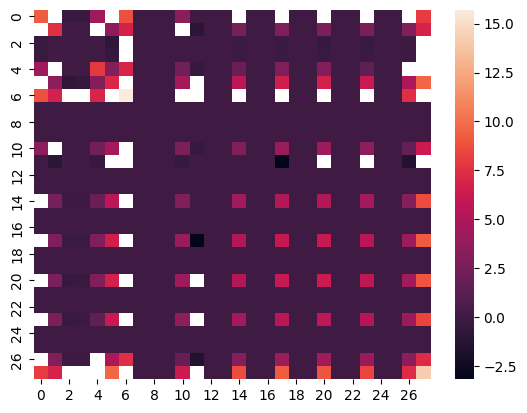

In [ ]:
import seaborn as sns
C=np.cov(np.transpose(X))
sns.heatmap(np.log(1+C));

(3034, 28)
(3034, 28)
(28, 28)


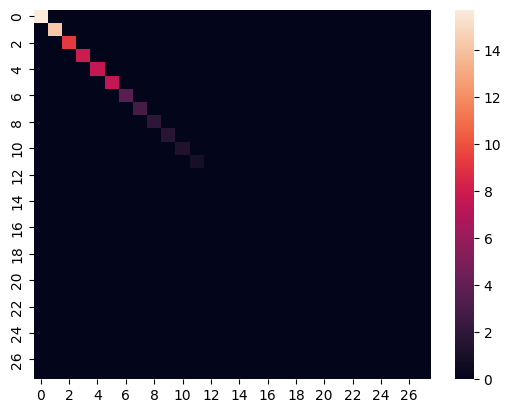

In [ ]:
pca = PCA() # по умолчанию сохраняем все компоненты
print(X.shape)
XPCAreduced = pca.fit_transform(X)   # Преобразовали данные X
print(X.shape)
C=np.cov(np.transpose(XPCAreduced))
print(C.shape)
sns.heatmap(np.log(1+C));

In [ ]:
for i in range (len(C)):
  print(f'{i}, {C[i,i]:.4f}') # дисперсия по компонентам

0, 6655101.1405
1, 1509698.8090
2, 10113.1492
3, 2675.3331
4, 2066.8439
5, 1716.8007
6, 36.8507
7, 16.7304
8, 5.3438
9, 4.5269
10, 2.7394
11, 1.5162
12, 0.0608
13, 0.0214
14, 0.0002
15, 0.0000
16, 0.0000
17, 0.0000
18, 0.0000
19, 0.0000
20, 0.0000
21, 0.0000
22, 0.0000
23, 0.0000
24, 0.0000
25, 0.0000
26, 0.0000
27, 0.0000


**ОБУЧИМ МОДЕЛЬ НА ПРЕОБРАЗОВАННЫХ ДАННЫХ**

28
(2123, 28)
Компонент использовано: 28, Accuracy на train: 0.8210
Компонент использовано: 27, Accuracy на train: 0.8210
Компонент использовано: 26, Accuracy на train: 0.8210
Компонент использовано: 25, Accuracy на train: 0.8262
Компонент использовано: 24, Accuracy на train: 0.8238
Компонент использовано: 23, Accuracy на train: 0.8285
Компонент использовано: 22, Accuracy на train: 0.8285
Компонент использовано: 21, Accuracy на train: 0.8285
Компонент использовано: 20, Accuracy на train: 0.8285
Компонент использовано: 19, Accuracy на train: 0.8295
Компонент использовано: 18, Accuracy на train: 0.8295
Компонент использовано: 17, Accuracy на train: 0.8295
Компонент использовано: 16, Accuracy на train: 0.8295
Компонент использовано: 15, Accuracy на train: 0.8290
Компонент использовано: 14, Accuracy на train: 0.8257
Компонент использовано: 13, Accuracy на train: 0.8262
Компонент использовано: 12, Accuracy на train: 0.8187
Компонент использовано: 11, Accuracy на train: 0.8187
Компонент испо

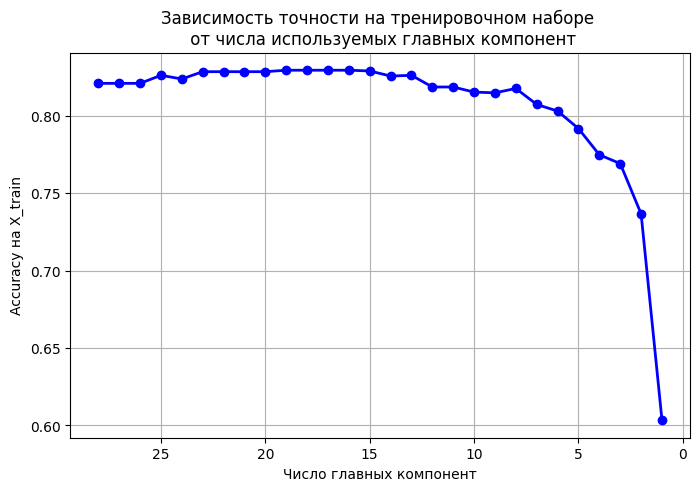

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(XPCAreduced, y, test_size=0.3, random_state=67)

num_components = len(feature_columns)
print(num_components)
print(X_train.shape)



accuracies_train = []
num_features_used = []

for n in range(num_components, 0, -1):   # берем компоненты начиная с 28 и до 1 с шагом -1
  X_train_subset = X_train[:, :n]  # остались все строки n столбцов

  tree = DecisionTreeClassifier(criterion='gini', max_depth=6,random_state=67)
  tree.fit(X_train_subset, y_train)

  accuracy_train = tree.score(X_train_subset, y_train)
  accuracies_train.append(accuracy_train)
  num_features_used.append(n)

  print(f"Компонент использовано: {n}, Accuracy на train: {accuracy_train:.4f}")
plt.figure(figsize=(8, 5))
plt.plot(num_features_used, accuracies_train, 'bo-', linewidth=2, markersize=6)
plt.title('Зависимость точности на тренировочном наборе \n от числа используемых главных компонент')
plt.xlabel('Число главных компонент')
plt.ylabel('Accuracy на X_train')
plt.grid(True)
plt.gca().invert_xaxis()
plt.show()

28
(2123, 28)


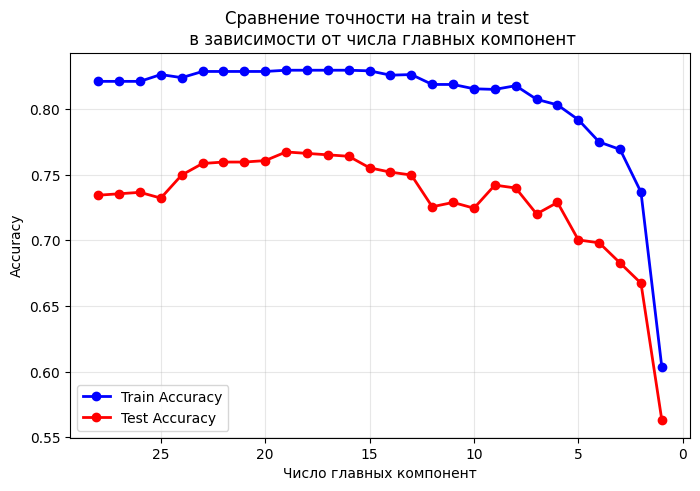

Лучшее число компонент:  19
Accuracy на test: 0.7673
Accuracy на train: 0.8295


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(XPCAreduced, y, test_size=0.3, random_state=67)

num_components = len(feature_columns)
print(num_components)
print(X_train.shape)



accuracies_train = []
accuracies_test = []
num_features_used = []


for n in range(num_components, 0, -1):   # берем компоненты начиная с 28 и до 1 с шагом -1
  X_train_subset = X_train[:, :n]  # остались все строки n столбцов
  X_test_subset = X_test[:, :n]

  tree = DecisionTreeClassifier(max_depth=6, random_state=42)
  tree.fit(X_train_subset, y_train)


  accuracy_train = tree.score(X_train_subset, y_train)
  accuracy_test = tree.score(X_test_subset, y_test)

  accuracies_train.append(accuracy_train)
  accuracies_test.append(accuracy_test)
  num_features_used.append(n)


plt.figure(figsize=(8, 5))
plt.plot(num_features_used, accuracies_train, 'bo-', linewidth=2, markersize=6, label='Train Accuracy')
plt.plot(num_features_used, accuracies_test, 'ro-', linewidth=2, markersize=6, label='Test Accuracy')
plt.title('Сравнение точности на train и test \n в зависимости от числа главных компонент')
plt.xlabel('Число главных компонент')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.gca().invert_xaxis()
plt.legend()
plt.show()


# Найдем оптимальное число компонент
max = np.argmax(accuracies_test)
best_n = num_features_used[max]
best_accuracy = accuracies_test[max]


print('Лучшее число компонент: ', best_n)
print(f"Accuracy на test: {best_accuracy:.4f}")
print(f"Accuracy на train: {accuracies_train[max]:.4f}")


**ТЕПЕРЬ ВЫКИНЕМ ВСЕ КРОМЕ ПУЛЬСАРОВ И БЛАЗАРОВ И ОБУЧИМСЯ НА ЭТОМ**

In [ ]:
blazars = ['bll', 'bcu', 'fsrq']
pulsars = ['psr']

In [ ]:
print('SourceType в изначальном df:', df['SourceType'].unique(), '\n')

clean = df['SourceType'].isin(blazars + pulsars)
df_clean = df[clean].copy()

print('SourceType в почищенном df:', df_clean['SourceType'].unique(), '\n')


print(df_clean['target'].value_counts(), '\n')


print('Размеры датафрейма: ', df_clean.shape)

SourceType в изначальном df: ['null' 'spp' 'bll' 'fsrq' 'bcu' 'psr' 'glc' 'snr' 'gal' 'sbg' 'hmb' 'rdg'
 'nlsy1' 'ssrq' 'pwn' 'bin' 'agn' 'css' 'sey' 'sfr' 'nov'] 

SourceType в почищенном df: ['bll' 'fsrq' 'bcu' 'psr'] 

target
 1    1717
-1     167
Name: count, dtype: int64 

Размеры датафрейма:  (1884, 31)


In [ ]:
feature_columns = [col for col in df_clean.columns if col not in ['Name', 'SourceType', 'target']]

X_c = df_clean[feature_columns]
y_c = df_clean['target']
y_c.shape

(1884,)

(1884, 28)


/tmp/ipython-input-1430630360.py:2: RuntimeWarning: invalid value encountered in log
  sns.heatmap(np.log(1+C));


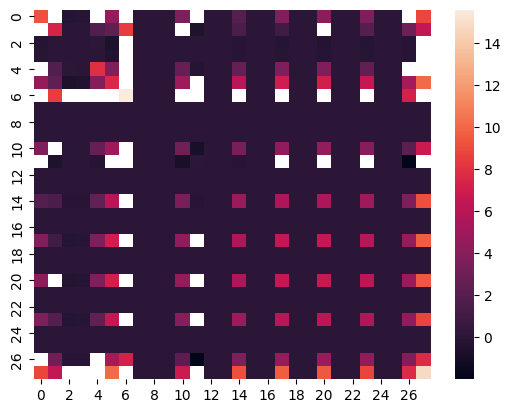

In [ ]:
C=np.cov(np.transpose(X_c))
sns.heatmap(np.log(1+C));
pca = PCA() # по умолчанию сохраняем все компоненты
print(X_c.shape)

(1884, 28)
(28, 28)


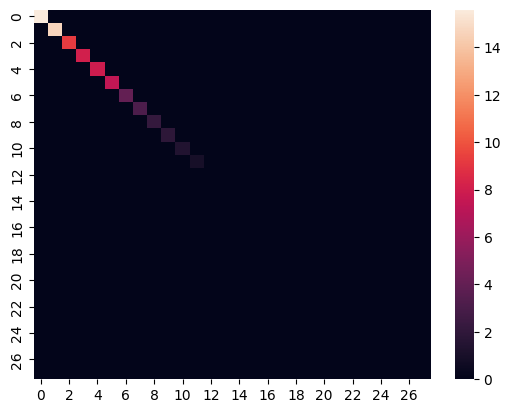

In [ ]:
XPCAreduced_c = pca.fit_transform(X_c)   # Преобразовали данные X
print(X_c.shape)
C=np.cov(np.transpose(XPCAreduced_c))
print(C.shape)
sns.heatmap(np.log(1+C));

28
(1318, 28)


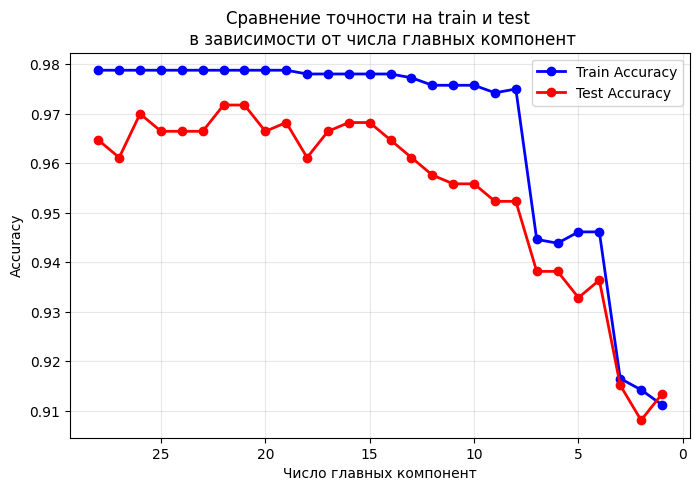

Лучшее число компонент:  22
Accuracy на test: 0.9717
Accuracy на train: 0.9788


In [ ]:

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(XPCAreduced_c, y_c, test_size=0.3, random_state=67)

num_components = len(feature_columns)
print(num_components)
print(X_train_c.shape)



accuracies_train = []
accuracies_test = []
num_features_used = []


for n in range(num_components, 0, -1):   # берем компоненты начиная с 28 и до 1 с шагом -1
  X_train_subset_c = X_train_c[:, :n]  # остались все строки n столбцов
  X_test_subset_c = X_test_c[:, :n]

  tree = DecisionTreeClassifier(max_depth=4, random_state=42)
  tree.fit(X_train_subset_c, y_train_c)


  accuracy_train = tree.score(X_train_subset_c, y_train_c)
  accuracy_test = tree.score(X_test_subset_c, y_test_c)

  accuracies_train.append(accuracy_train)
  accuracies_test.append(accuracy_test)
  num_features_used.append(n)


plt.figure(figsize=(8, 5))
plt.plot(num_features_used, accuracies_train, 'bo-', linewidth=2, markersize=6, label='Train Accuracy')
plt.plot(num_features_used, accuracies_test, 'ro-', linewidth=2, markersize=6, label='Test Accuracy')
plt.title('Сравнение точности на train и test \n в зависимости от числа главных компонент')
plt.xlabel('Число главных компонент')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.gca().invert_xaxis()
plt.legend()
plt.show()


# Найдем оптимальное число компонент
max = np.argmax(accuracies_test)
best_n = num_features_used[max]
best_accuracy = accuracies_test[max]


print('Лучшее число компонент: ', best_n)
print(f"Accuracy на test: {best_accuracy:.4f}")
print(f"Accuracy на train: {accuracies_train[max]:.4f}")

0.9646643109540636
Истинное число блазаров:  520
Истинное число пульсаров:  46


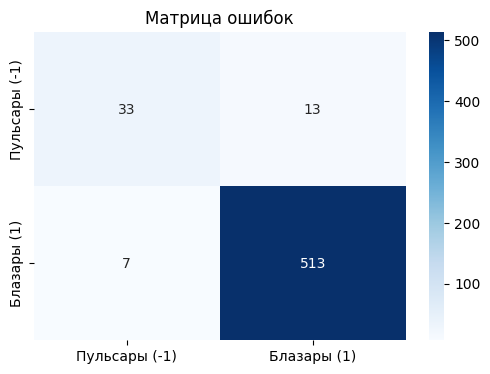

precision:  0.825
recall:  0.717391304347826


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(XPCAreduced_c, y_c, test_size=0.3, random_state=67)


tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train_c, y_train_c)
y_pred = tree.predict(X_test_c)  # предсказание модели


accuracy = tree.score(X_test_c, y_test_c)  # accuracy на тестовых данных
print(accuracy)


num_blazars = (y_test_c == 1).sum()
num_pulsars = (y_test_c == -1).sum()

print('Истинное число блазаров: ', num_blazars)
print('Истинное число пульсаров: ', num_pulsars)



cm = confusion_matrix(y_test_c, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Пульсары (-1)', 'Блазары (1)'], yticklabels=['Пульсары (-1)', 'Блазары (1)'])
plt.title('Матрица ошибок')
plt.show()


precision = cm[0,0] / (cm[1,0] + cm[0,0])
recall = cm[0,0] / (cm[0,1] + cm[0,0])





print('precision: ', precision)
print('recall: ', recall)

РАЗМНОЖИМ ***ДАННЫЕ***
------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
feature_columns = [col for col in df_clean.columns if col not in ['Name', 'SourceType', 'target']]
X = df_clean[feature_columns]
y = df_clean['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=67)

In [ ]:
train_data = pd.concat([X_train, y_train], axis=1)
pulsars_train = train_data[train_data['target'] == -1]
train_balanced = pd.concat([train_data, pulsars_train, pulsars_train, pulsars_train, pulsars_train])
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
print(train_balanced['target'].value_counts())

target
 1    1197
-1     605
Name: count, dtype: int64


0.9611307420494699


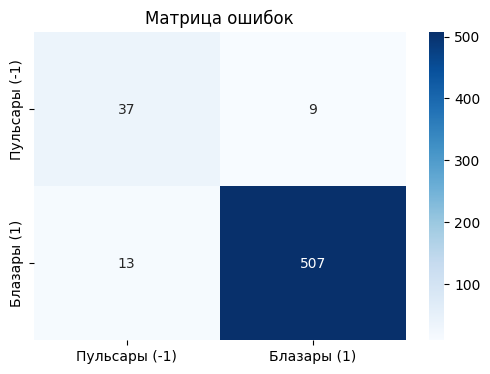

precision:  0.74
recall:  0.8043478260869565


In [ ]:

X_train_bal = train_balanced[feature_columns]
y_train_bal = train_balanced['target']

pca = PCA()
XPCAreduced_train = pca.fit_transform(X_train_bal)
XPCAreduced_test = pca.transform(X_test)

tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(XPCAreduced_train, y_train_bal)


y_pred = tree.predict(XPCAreduced_test)
accuracy = tree.score(XPCAreduced_test, y_test)

print(accuracy)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Пульсары (-1)', 'Блазары (1)'], yticklabels=['Пульсары (-1)', 'Блазары (1)'])
plt.title('Матрица ошибок')
plt.show()

precision = cm[0,0] / (cm[1,0] + cm[0,0])
recall = cm[0,0] / (cm[0,1] + cm[0,0])




print('precision: ', precision)
print('recall: ', recall)

***Обучимся используя feature_importances***


In [ ]:
df_clean

,Name,RA,Dec,Par1,Par2,Par3,Par4,Par5,Par6,Par7,...,Par19,Par20,Par21,Par22,Par23,Par24,Par25,Par26,SourceType,target
3,J0001.2-0748,0.3209,-7.8159,0.0503,0.0429,-19.47,11.253,1263.84,4.853900e-13,6.952200e-10,...,6.997,2.106892e-10,1.421389e-12,8.018,1.005633e-11,1.686281e-13,1.574,49.73821,bll,1
4,J0001.4+2120,0.3612,21.3379,0.1298,0.1162,-32.55,11.350,310.68,2.522100e-11,2.944900e-10,...,4.517,8.413887e-15,4.392482e-17,0.000,1.035538e-14,9.594525e-17,0.000,130.33630,fsrq,1
7,J0002.2-4152,0.5621,-41.8828,0.1337,0.0860,68.13,5.158,1956.04,7.324000e-14,2.714000e-10,...,1.513,9.763049e-11,6.633214e-13,4.735,2.590360e-11,4.448439e-13,2.584,56.35106,bcu,1
9,J0003.2-5246,0.8152,-52.7771,0.0430,0.0377,-44.41,5.670,3676.23,1.998800e-14,2.590400e-10,...,3.079,7.936658e-11,5.517048e-13,3.738,2.977405e-11,5.533345e-13,4.510,45.28044,bcu,1
12,J0003.8-1151,0.9588,-11.8627,0.0801,0.0618,-16.73,4.181,2315.88,4.415200e-14,2.339000e-10,...,3.793,4.661099e-11,3.191276e-13,2.465,1.772286e-11,3.124540e-13,2.541,48.49165,bcu,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3027,J2358.2-1022,359.5502,-10.3699,0.1558,0.1312,58.86,6.358,368.79,6.646600e-12,2.274900e-10,...,2.343,6.816563e-13,4.276634e-15,0.000,4.451705e-12,5.964652e-14,0.488,68.61301,fsrq,1
3028,J2358.3-2853,359.5980,-28.8910,0.0764,0.0673,-39.28,6.234,970.00,4.395500e-13,2.884900e-10,...,2.351,8.747450e-11,5.724407e-13,5.046,2.301750e-15,3.495638e-17,0.000,45.93385,bcu,1
3031,J2358.9+3926,359.7360,39.4476,0.1079,0.0879,10.36,4.685,2167.58,7.458300e-14,3.395000e-10,...,3.687,2.752512e-12,1.844227e-14,0.145,4.889366e-11,8.012898e-13,4.207,52.85284,fsrq,1
3032,J2359.3-3038,359.8291,-30.6465,0.0335,0.0314,-6.68,11.055,2239.89,1.199900e-13,5.943200e-10,...,6.609,1.267952e-10,8.683160e-13,6.162,5.573432e-11,9.833648e-13,6.002,40.96702,bll,1


Важность исходных признаков по DecisionTree:
   feature  importance
10    Par9    0.571299
27   Par26    0.243340
11   Par10    0.070258
20   Par19    0.047590
23   Par22    0.026563
26   Par25    0.013996
13   Par12    0.013866
24   Par23    0.007911
6     Par5    0.005177
2     Par1    0.000000
3     Par2    0.000000
0       RA    0.000000
8     Par7    0.000000
9     Par8    0.000000
5     Par4    0.000000
7     Par6    0.000000
4     Par3    0.000000
1      Dec    0.000000
14   Par13    0.000000
12   Par11    0.000000
19   Par18    0.000000
18   Par17    0.000000
17   Par16    0.000000
16   Par15    0.000000
15   Par14    0.000000
21   Par20    0.000000
22   Par21    0.000000
25   Par24    0.000000


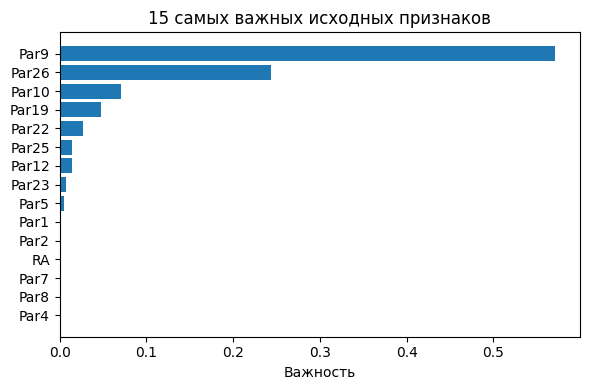

1.0
9


In [ ]:
feature_columns = [col for col in df_clean.columns if col not in ['Name', 'SourceType', 'target']]
X_original = df_clean[feature_columns]
y_original = df_clean['target']

tree_original = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_original.fit(X_original, y_original)

importances = tree_original.feature_importances_

feature_importance_df = pd.DataFrame({'feature': feature_columns, 'importance': importances}).sort_values('importance', ascending=False)

print("Важность исходных признаков по DecisionTree:")
print(feature_importance_df)

# 15 самых важных признаков
plt.figure(figsize=(6, 4))
plt.barh(feature_importance_df['feature'][:15][::-1], feature_importance_df['importance'][:15][::-1])
plt.title('15 самых важных исходных признаков')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

# Суммарная важность
print(importances.sum())
print((importances > 0).sum())

Признаков: 28 | Train: 0.9833 | Test: 0.9735
Признаков: 27 | Train: 0.9833 | Test: 0.9753
Признаков: 26 | Train: 0.9833 | Test: 0.9753
Признаков: 25 | Train: 0.9833 | Test: 0.9700
Признаков: 24 | Train: 0.9833 | Test: 0.9770
Признаков: 23 | Train: 0.9833 | Test: 0.9770
Признаков: 22 | Train: 0.9833 | Test: 0.9770
Признаков: 21 | Train: 0.9833 | Test: 0.9753
Признаков: 20 | Train: 0.9833 | Test: 0.9735
Признаков: 19 | Train: 0.9833 | Test: 0.9753
Признаков: 18 | Train: 0.9833 | Test: 0.9735
Признаков: 17 | Train: 0.9833 | Test: 0.9735
Признаков: 16 | Train: 0.9833 | Test: 0.9788
Признаков: 15 | Train: 0.9833 | Test: 0.9735
Признаков: 14 | Train: 0.9833 | Test: 0.9753
Признаков: 13 | Train: 0.9833 | Test: 0.9788
Признаков: 12 | Train: 0.9833 | Test: 0.9788
Признаков: 11 | Train: 0.9833 | Test: 0.9788
Признаков: 10 | Train: 0.9833 | Test: 0.9770
Признаков: 9 | Train: 0.9833 | Test: 0.9770
Признаков: 8 | Train: 0.9833 | Test: 0.9770
Признаков: 7 | Train: 0.9833 | Test: 0.9770
Признаков: 6 

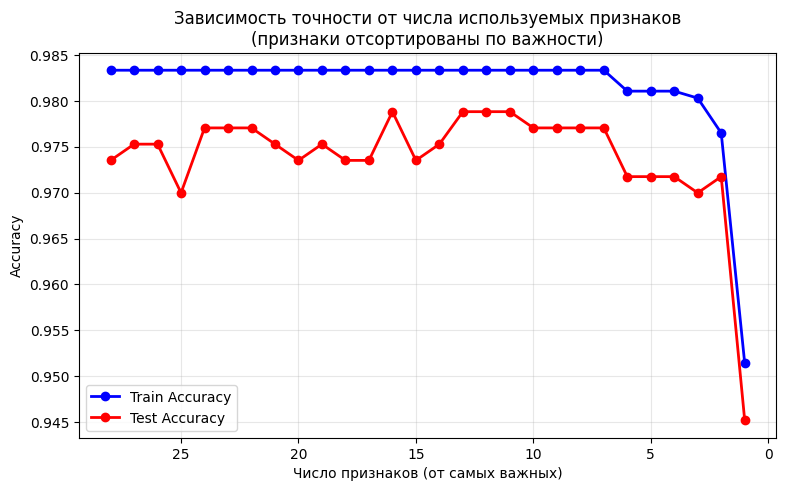

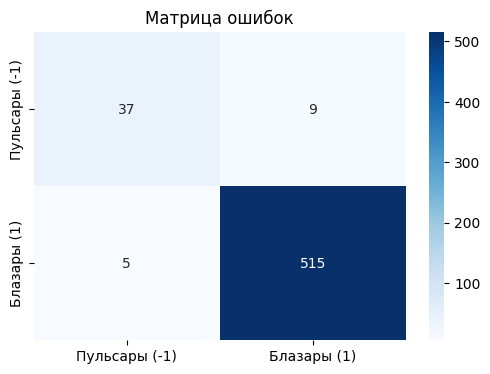

precision:  0.8809523809523809
recall:  0.8043478260869565


In [ ]:
# сортируем признаки
sorted_features = feature_importance_df.sort_values('importance', ascending=True)['feature'].values

accuracies_train = []
accuracies_test = []
num_features_used = []


X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(X_original, y_original, test_size=0.3, random_state=67)



for n in range(len(sorted_features), 0, -1):
  features_to_use = sorted_features[-n:]

  X_train_sub = X_train_orig[features_to_use]
  X_test_sub = X_test_orig[features_to_use]


  tree = DecisionTreeClassifier(max_depth=4, random_state=42)
  tree.fit(X_train_sub, y_train_orig)

    # accuracy
  acc_train = tree.score(X_train_sub, y_train_orig)
  acc_test = tree.score(X_test_sub, y_test_orig)

  accuracies_train.append(acc_train)
  accuracies_test.append(acc_test)
  num_features_used.append(n)

  print(f"Признаков: {n} | Train: {acc_train:.4f} | Test: {acc_test:.4f}")


plt.figure(figsize=(9, 5))
plt.plot(num_features_used, accuracies_train, 'bo-', linewidth=2, markersize=6, label='Train Accuracy')
plt.plot(num_features_used, accuracies_test, 'ro-', linewidth=2, markersize=6, label='Test Accuracy')
plt.title('Зависимость точности от числа используемых признаков\n(признаки отсортированы по важности)')
plt.xlabel('Число признаков (от самых важных)')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.gca().invert_xaxis()
plt.legend()
plt.show()




tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train_orig, y_train_orig)

y_pred_orig = tree.predict(X_test_orig)


cm = confusion_matrix(y_test_orig, y_pred_orig)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Пульсары (-1)', 'Блазары (1)'], yticklabels=['Пульсары (-1)', 'Блазары (1)'])
plt.title('Матрица ошибок')
plt.show()

precision = cm[0,0] / (cm[1,0] + cm[0,0])
recall = cm[0,0] / (cm[0,1] + cm[0,0])

print('precision: ', precision)
print('recall: ', recall)